In [24]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("A:/AI/Datasets/IBM_HR_Analytics_dataset.csv")
print(data.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')


In [2]:
label_cols = ['Attrition',"OverTime", "Gender"]

label_encoder = LabelEncoder()

for c in label_cols:
    data[c] = label_encoder.fit_transform(data[c])


In [3]:
categorical_columns = [
    'BusinessTravel', 'Department', 'EducationField',
    'JobRole', 'MaritalStatus', 'Over18'
]

data = pd.get_dummies(data,
    columns=categorical_columns,
    drop_first=True
)

x = data.drop(columns='Attrition')
y = data['Attrition']
  

In [4]:
#random forest classifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=200,
    max_depth=15,random_state=42)

x_rf_tr,x_rf_te,y_rf_tr,y_rf_te = train_test_split(x,y,test_size=0.3,random_state=42)

random_forest.fit(x_rf_tr,y_rf_tr)

y_rf_pr = random_forest.predict(x_rf_te)

In [5]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(f"Random Forest classification report :\n{classification_report(y_rf_te,y_rf_pr)})")
print()
print(f"Confusion matrix for Random Forest classifier :\n{confusion_matrix(y_rf_te,y_rf_pr)}")
print()
print(f"Accuracy_score for Random Forest :{accuracy_score(y_rf_te,y_rf_pr)}")

Random Forest classification report :
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       380
           1       0.62      0.08      0.14        61

    accuracy                           0.87       441
   macro avg       0.75      0.54      0.54       441
weighted avg       0.84      0.87      0.82       441
)

Confusion matrix for Random Forest classifier :
[[377   3]
 [ 56   5]]

Accuracy_score for Random Forest :0.8662131519274376


In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
'min_samples_split':[25,26,35,40],
'min_samples_leaf':[10,13,15,17],
'class_weight':['balanced']}

grid_rf = GridSearchCV(
    random_forest,
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    cv=6)

grid_rf.fit(x_rf_tr,y_rf_tr)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'min_samples_leaf': [10, 13, ...], 'min_samples_split': [25, 26, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, d

In [7]:
print(grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

print()
print(best_rf)


{'class_weight': 'balanced', 'min_samples_leaf': 17, 'min_samples_split': 40}

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=17, min_samples_split=40,
                       n_estimators=200, random_state=42)


In [8]:
#using the best parameters found to the current random forest to verify whether the accuracy has any changes

random_forest = RandomForestClassifier(n_estimators=200,
    max_depth=15,class_weight='balanced', min_samples_leaf=10,
                       min_samples_split=26,random_state=42)

x_rf_tr,x_rf_te,y_rf_tr,y_rf_te = train_test_split(x,y,test_size=0.3,random_state=42)

random_forest.fit(x_rf_tr,y_rf_tr)

y_rf_pr = random_forest.predict(x_rf_te)

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(f"Hyperparamter Tuned Random Forest classification report :\n{classification_report(y_rf_te,y_rf_pr)})")
print()
print(f"Confusion matrix for Hyperparamter Tuned Random Forest classifier :\n{confusion_matrix(y_rf_te,y_rf_pr)}")
print()
print(f"Accuracy_score for Hyperparamter Tuned Random Forest :{accuracy_score(y_rf_te,y_rf_pr)}")

Hyperparamter Tuned Random Forest classification report :
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       380
           1       0.34      0.49      0.40        61

    accuracy                           0.80       441
   macro avg       0.62      0.67      0.64       441
weighted avg       0.83      0.80      0.81       441
)

Confusion matrix for Hyperparamter Tuned Random Forest classifier :
[[321  59]
 [ 31  30]]

Accuracy_score for Hyperparamter Tuned Random Forest :0.7959183673469388


In [11]:
#To further improve the model's performance ,Let's use SMOTE to avoid the model's imbalance in dataset

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_tr_smote,y_tr_smote = smote.fit_resample(x_rf_tr,y_rf_tr)

print("Before smote :",y_rf_tr.shape)
print("After smote :",y_tr_smote.shape)

Before smote : (1029,)
After smote : (1706,)


In [13]:
random_forest = RandomForestClassifier(n_estimators=200,
    max_depth=15,class_weight='balanced', min_samples_leaf=10,
                       min_samples_split=26,random_state=42)

random_forest.fit(x_tr_smote,y_tr_smote)

y_rf_pr_smote = random_forest.predict(x_rf_te)

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(f"Hyperparamter Tuned and Smote sampled Random Forest classification report :\n{classification_report(y_rf_te,y_rf_pr_smote)})")
print()
print(f"Confusion matrix for Hyperparamter Tuned and Smote sampled Random Forest classifier :\n{confusion_matrix(y_rf_te,y_rf_pr_smote)}")
print()
print(f"Accuracy_score for Hyperparamter Tuned and Smote sampled Random Forest :{accuracy_score(y_rf_te,y_rf_pr_smote)}")

Hyperparamter Tuned and Smote sampled Random Forest classification report :
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       380
           1       0.44      0.43      0.43        61

    accuracy                           0.85       441
   macro avg       0.67      0.67      0.67       441
weighted avg       0.84      0.85      0.84       441
)

Confusion matrix for Hyperparamter Tuned and Smote sampled Random Forest classifier :
[[347  33]
 [ 35  26]]

Accuracy_score for Hyperparamter Tuned and Smote sampled Random Forest :0.8458049886621315


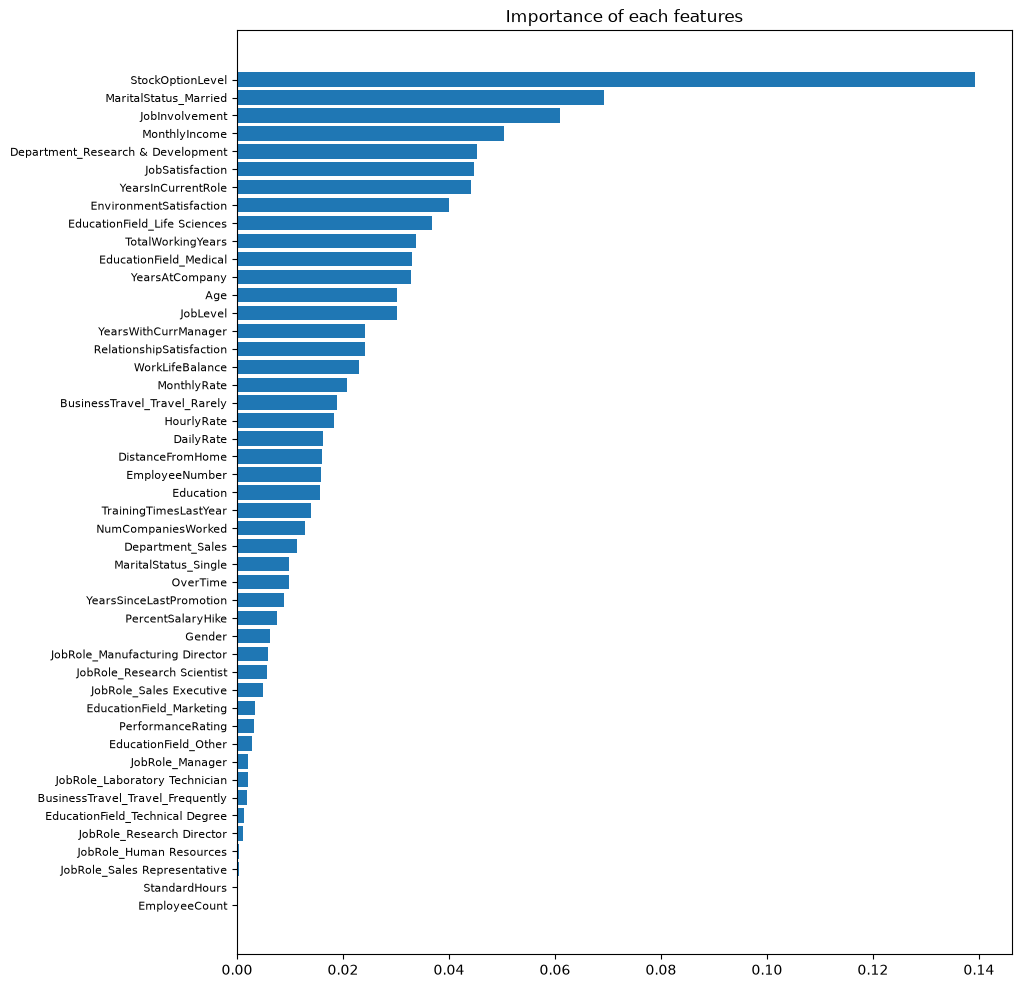

In [ ]:
#visualization and plotting
import numpy as np
import matplotlib.pyplot as plt

#plotting feature importance
importance = random_forest.feature_importances_
features = x_rf_tr.columns
indices = np.argsort(importance)

plt.figure(figsize=(10,12))
plt.barh(range(len(indices)),importance[indices])
plt.yticks(range(len(indices)),features[indices],fontsize=8)
plt.title("Top Features Influencing Employee Attrition (Random Forest Model)")
plt.show()
